# Zomato Restaurant Insights 

# Project Objective

#### The purpose of this project is to analyze Zomato restaurant data to understand customer preferences, restaurant performance, pricing patterns, and ratings. The insights can help restaurant owners improve their services and assist customers in making better dining choices.

# Business Questions

1. Which cities have the highest number of restaurants listed on Zomato?

2. Which cuisines are the most popular among customers?

3. What is the average cost for two people across different cities?

4. Do restaurants offering online delivery receive higher customer ratings than those that do not?

5. Do restaurants with table booking have better ratings compared to those without table booking?

6. Which restaurants have the highest customer ratings and the most votes?

7. Is there a relationship between the number of customer votes and restaurant ratings?

8. Which price range (Low, Medium, High) contains the largest number of restaurants?

9. Which cities have the highest average restaurant ratings?

10. What are the key factors (price, cuisine, online delivery, table booking, and votes) that influence restaurant ratings?


# Data Understanding

1. Import Necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

2. Load dataset

In [2]:
data = pd.read_csv(r'C:\Users\zomato_restaurants_in_India.csv', encoding='latin1')

3. Display Sample Records

In [3]:
data.head()

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,...,2,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154,0.0,-1,-1
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,...,2,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161,0.0,-1,-1
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,27.182938,77.979684,...,1,Rs.,"['No Alcohol Available', 'Dinner', 'Takeaway A...",4.2,Very Good,801,107,0.0,1,-1
3,3400290,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-civi...,"Near Anjana Cinema, Nehru Nagar, Civil Lines, ...",Agra,34,Civil Lines,27.205668,78.004799,...,1,Rs.,"['Takeaway Available', 'Credit Card', 'Lunch',...",4.3,Very Good,693,157,0.0,1,-1
4,3401744,The Salt Cafe Kitchen & Bar,['Casual Dining'],https://www.zomato.com/agra/the-salt-cafe-kitc...,"1C,3rd Floor, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.157709,78.052421,...,3,Rs.,"['Lunch', 'Serves Alcohol', 'Cash', 'Credit Ca...",4.9,Excellent,470,291,0.0,1,-1


4. Dataset dimensions

In [4]:
data.shape

(211944, 26)

5. Data types

In [5]:
data.dtypes

res_id                    int64
name                     object
establishment            object
url                      object
address                  object
city                     object
city_id                   int64
locality                 object
latitude                float64
longitude               float64
zipcode                  object
country_id                int64
locality_verbose         object
cuisines                 object
timings                  object
average_cost_for_two      int64
price_range               int64
currency                 object
highlights               object
aggregate_rating        float64
rating_text              object
votes                     int64
photo_count               int64
opentable_support       float64
delivery                  int64
takeaway                  int64
dtype: object

In [6]:
data.info

<bound method DataFrame.info of           res_id                            name      establishment  \
0        3400299                     Bikanervala    ['Quick Bites']   
1        3400005  Mama Chicken Mama Franky House    ['Quick Bites']   
2        3401013                   Bhagat Halwai    ['Quick Bites']   
3        3400290                   Bhagat Halwai    ['Quick Bites']   
4        3401744     The Salt Cafe Kitchen & Bar  ['Casual Dining']   
...          ...                             ...                ...   
211939   3202251  Kali Mirch Cafe And Restaurant  ['Casual Dining']   
211940   3200996                      Raju Omlet    ['Quick Bites']   
211941  18984164                The Grand Thakar  ['Casual Dining']   
211942   3201138                          Subway    ['Quick Bites']   
211943  18879846     Freshco's - The Health Cafe          ['CafÃ©']   

                                                      url  \
0       https://www.zomato.com/agra/bikanervala-khanda

6. Column Information

In [7]:
data.columns

Index(['res_id', 'name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway'],
      dtype='object')

7. Statistical Summary

In [8]:
data.describe

<bound method NDFrame.describe of           res_id                            name      establishment  \
0        3400299                     Bikanervala    ['Quick Bites']   
1        3400005  Mama Chicken Mama Franky House    ['Quick Bites']   
2        3401013                   Bhagat Halwai    ['Quick Bites']   
3        3400290                   Bhagat Halwai    ['Quick Bites']   
4        3401744     The Salt Cafe Kitchen & Bar  ['Casual Dining']   
...          ...                             ...                ...   
211939   3202251  Kali Mirch Cafe And Restaurant  ['Casual Dining']   
211940   3200996                      Raju Omlet    ['Quick Bites']   
211941  18984164                The Grand Thakar  ['Casual Dining']   
211942   3201138                          Subway    ['Quick Bites']   
211943  18879846     Freshco's - The Health Cafe          ['CafÃ©']   

                                                      url  \
0       https://www.zomato.com/agra/bikanervala-khan

8. Missing Values

In [9]:
data.isnull().sum()

res_id                       0
name                         0
establishment                0
url                          0
address                    134
city                         0
city_id                      0
locality                     0
latitude                     0
longitude                    0
zipcode                 163187
country_id                   0
locality_verbose             0
cuisines                  1391
timings                   3874
average_cost_for_two         0
price_range                  0
currency                     0
highlights                   0
aggregate_rating             0
rating_text                  0
votes                        0
photo_count                  0
opentable_support           48
delivery                     0
takeaway                     0
dtype: int64

9. Duplicate Records

In [10]:
data.duplicated().sum()

np.int64(151527)

10. Unique values

In [11]:
data.nunique()

res_id                  55568
name                    41100
establishment              27
url                     55568
address                 50657
city                       99
city_id                    83
locality                 3731
latitude                53362
longitude               53326
zipcode                  1311
country_id                  1
locality_verbose         3910
cuisines                 9382
timings                  7740
average_cost_for_two      145
price_range                 4
currency                    1
highlights              31455
aggregate_rating           33
rating_text                39
votes                    2644
photo_count              2514
opentable_support           1
delivery                    3
takeaway                    1
dtype: int64

# Data Understanding - Observations

- The dataset contains **211,944 restaurant records** with **26 columns**.

- The dataset consists of both **numerical and categorical features**:
  - Numerical columns include **average_cost_for_two, aggregate_rating, votes, photo_count, latitude, and longitude**, which are suitable for calculations and analysis.
  - Categorical columns include **restaurant name, city, locality, cuisines, timings, and rating_text**, which provide details about restaurant characteristics.

- Most columns are complete and contain no missing values.
- The **zipcode** column has **163,187 missing values**, so it can be removed as it does not add significant value to the analysis.
- Columns such as **address, cuisines, timings, and opentable_support** contain a small number of missing values and require basic cleaning.

- The dataset contains **151,527 duplicate records**, which need to be removed before analysis to avoid incorrect insights.

- The dataset provides useful information about:
  - **Restaurant details** (name, establishment type, cuisines)
  - **Location details** (city, locality, latitude, longitude)
  - **Pricing details** (average cost for two, price range)
  - **Customer feedback** (ratings and votes)
  - **Services offered** (delivery, takeaway, and table booking support)

- Minor data type changes are required:
  - Convert **opentable_support** into a categorical column.
  - Convert **delivery** and **takeaway** values from 0/1 format into Yes/No categories for easier interpretation.
  - Treat **price_range** as a category rather than a numerical value.

- After removing duplicates, handling missing values, and making necessary data type changes, the dataset is ready for exploratory data analysis and dashboard creation.


# Data Cleaning 

In [5]:
data["opentable_support"] = data["opentable_support"].astype("object")

In [6]:
data["delivery"] = data["delivery"].map({1:"Yes", 0:"No"})
data["takeaway"] = data["takeaway"].map({1:"Yes", 0:"No"})


In [7]:
data["price_range"] = data["price_range"].astype("category")

In [8]:
data.dtypes

res_id                     int64
name                      object
establishment             object
url                       object
address                   object
city                      object
city_id                    int64
locality                  object
latitude                 float64
longitude                float64
zipcode                   object
country_id                 int64
locality_verbose          object
cuisines                  object
timings                   object
average_cost_for_two       int64
price_range             category
currency                  object
highlights                object
aggregate_rating         float64
rating_text               object
votes                      int64
photo_count                int64
opentable_support         object
delivery                  object
takeaway                  object
dtype: object

In [9]:
data.head()

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,...,2,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154,0.0,NaN,NaN
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,...,2,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161,0.0,NaN,NaN
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,27.182938,77.979684,...,1,Rs.,"['No Alcohol Available', 'Dinner', 'Takeaway A...",4.2,Very Good,801,107,0.0,Yes,NaN
3,3400290,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-civi...,"Near Anjana Cinema, Nehru Nagar, Civil Lines, ...",Agra,34,Civil Lines,27.205668,78.004799,...,1,Rs.,"['Takeaway Available', 'Credit Card', 'Lunch',...",4.3,Very Good,693,157,0.0,Yes,NaN
4,3401744,The Salt Cafe Kitchen & Bar,['Casual Dining'],https://www.zomato.com/agra/the-salt-cafe-kitc...,"1C,3rd Floor, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.157709,78.052421,...,3,Rs.,"['Lunch', 'Serves Alcohol', 'Cash', 'Credit Ca...",4.9,Excellent,470,291,0.0,Yes,NaN


In [10]:
data = data.drop_duplicates()

In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
data1 = data.copy()

In [13]:
data["cuisines"].fillna("Unknown", inplace=True)

In [14]:
data["timings"].fillna("Not Available", inplace=True)

In [15]:
data["address"].fillna("Not Available", inplace=True)

In [44]:
data["opentable_support"].fillna("No", inplace=True)

In [17]:
data.drop("zipcode", axis=1, inplace=True)

In [18]:
data["delivery"] = data["delivery"].fillna(0)
data["takeaway"] = data["takeaway"].fillna(0)

In [19]:
data.isnull().sum()

res_id                  0
name                    0
establishment           0
url                     0
address                 0
city                    0
city_id                 0
locality                0
latitude                0
longitude               0
country_id              0
locality_verbose        0
cuisines                0
timings                 0
average_cost_for_two    0
price_range             0
currency                0
highlights              0
aggregate_rating        0
rating_text             0
votes                   0
photo_count             0
opentable_support       0
delivery                0
takeaway                0
dtype: int64

In [20]:
data["aggregate_rating"].describe()

count    60417.000000
mean         3.032868
std          1.440751
min          0.000000
25%          2.900000
50%          3.500000
75%          4.000000
max          4.900000
Name: aggregate_rating, dtype: float64

In [21]:
data["average_cost_for_two"].describe()

count    60417.000000
mean       538.304517
std        593.852227
min          0.000000
25%        200.000000
50%        400.000000
75%        600.000000
max      30000.000000
Name: average_cost_for_two, dtype: float64

In [22]:
data[data["average_cost_for_two"] >= 10000][["name", "city", "average_cost_for_two"]]

,name,city,average_cost_for_two
19730,Fly Dining,Bangalore,14000
77501,Gol Bungalow - Taj Falaknuma Palace,Hyderabad,15000
100988,Risala- Umaid Bhawan Palace,Jodhpur,12000
101040,Pillars - Umaid Bhawan Palace,Jodhpur,12000
101041,Trophy Bar- Umaid Bhawan Palace,Jodhpur,12000
135918,Wasabi By Morimoto - The Taj Mahal Palace,Mumbai,10000
136240,Ocean - The Private Dining Room - Sahara Star,Mumbai,30000
197677,Bhairo,Udaipur,15000


In [23]:
data["res_id"].duplicated().sum()

np.int64(4849)

In [24]:
data[data["res_id"].duplicated(keep=False)].sort_values("res_id").head(10)

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,...,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
57196,89,Naivedyam,['Casual Dining'],https://www.zomato.com/ncr/naivedyam-hauz-khas...,"Shop 1, Hauz Khas Village, New Delhi",New Delhi,1,Hauz Khas Village,28.554847,77.195051,...,2,Rs.,"['Delivery', 'Dinner', 'Credit Card', 'Breakfa...",4.1,Very Good,2559,1721,0.0,Yes,0
56767,89,Naivedyam,['Casual Dining'],https://www.zomato.com/ncr/naivedyam-hauz-khas...,"Shop 1, Hauz Khas Village, New Delhi",New Delhi,1,Hauz Khas Village,28.554847,77.195051,...,2,Rs.,"['Delivery', 'Dinner', 'Credit Card', 'Breakfa...",4.1,Very Good,2559,1721,0.0,0,0
57669,121,Kwality,['Fine Dining'],https://www.zomato.com/ncr/kwality-connaught-p...,"7, Regal Building, Connaught Place, New Delhi",New Delhi,1,Connaught Place,28.629820,77.217363,...,4,Rs.,"['Lunch', 'Cash', 'Credit Card', 'Dinner', 'Ta...",4.1,Very Good,347,400,0.0,Yes,0
54170,121,Kwality,['Fine Dining'],https://www.zomato.com/ncr/kwality-connaught-p...,"7, Regal Building, Connaught Place, New Delhi",New Delhi,1,Connaught Place,28.629820,77.217363,...,4,Rs.,"['Lunch', 'Cash', 'Credit Card', 'Dinner', 'Ta...",4.1,Very Good,347,400,0.0,0,0
53956,122,Lazeez Affaire,['Casual Dining'],https://www.zomato.com/ncr/lazeez-affaire-chan...,"6/48, Malcha Marg Market, Chanakyapuri, New Delhi",New Delhi,1,Chanakyapuri,28.602231,77.186106,...,4,Rs.,"['Cash', 'Credit Card', 'Debit Card', 'Deliver...",4.8,Excellent,1707,1770,0.0,0,0
55988,122,Lazeez Affaire,['Casual Dining'],https://www.zomato.com/ncr/lazeez-affaire-chan...,"6/48, Malcha Marg Market, Chanakyapuri, New Delhi",New Delhi,1,Chanakyapuri,28.602231,77.186106,...,4,Rs.,"['Cash', 'Credit Card', 'Debit Card', 'Deliver...",4.8,Excellent,1707,1770,0.0,Yes,0
56773,413,Naivedyam,['Casual Dining'],https://www.zomato.com/ncr/naivedyam-sushant-l...,"Vipul Square, B Block, Sushant Lok, Gurgaon",Gurgaon,1,Sushant Lok,28.465038,77.078697,...,2,Rs.,"['Credit Card', 'No Alcohol Available', 'Cash'...",4.1,Very Good,2081,881,0.0,Yes,0
57750,413,Naivedyam,['Casual Dining'],https://www.zomato.com/ncr/naivedyam-sushant-l...,"Vipul Square, B Block, Sushant Lok, Gurgaon",Gurgaon,1,Sushant Lok,28.465038,77.078697,...,2,Rs.,"['Credit Card', 'No Alcohol Available', 'Cash'...",4.1,Very Good,2081,881,0.0,Yes,0
53958,463,Karim's,['Casual Dining'],https://www.zomato.com/ncr/karims-jama-masjid-...,"16, Gali Kababian, Jama Masjid, New Delhi",New Delhi,1,Jama Masjid,28.649522,77.233661,...,2,Rs.,"['Cash', 'Takeaway Available', 'Breakfast', 'L...",4.0,Very Good,6724,3103,0.0,0,0
57904,463,Karim's,['Casual Dining'],https://www.zomato.com/ncr/karims-jama-masjid-...,"16, Gali Kababian, Jama Masjid, New Delhi",New Delhi,1,Jama Masjid,28.649522,77.233661,...,2,Rs.,"['Breakfast', 'Lunch', 'Cash', 'Takeaway Avail...",4.0,Very Good,6724,3103,0.0,0,0


In [25]:
data[data["res_id"].duplicated(keep=False)][
    ["res_id", "name", "city", "locality"]
].sort_values("res_id")

,res_id,name,city,locality
57196,89,Naivedyam,New Delhi,Hauz Khas Village
56767,89,Naivedyam,New Delhi,Hauz Khas Village
57669,121,Kwality,New Delhi,Connaught Place
54170,121,Kwality,New Delhi,Connaught Place
53956,122,Lazeez Affaire,New Delhi,Chanakyapuri
...,...,...,...,...
107492,19145465,City Bites,Kharagpur,Kharagpur Rly Settlement
179836,19151164,ER Hyderabad Briyani,Salem,Suramangalam
180003,19151164,ER Hyderabad Briyani,Salem,Suramangalam
91319,19153007,Goli Vada Pav No.1,Jalandhar,Model Town


In [26]:
data.drop_duplicates(subset="res_id", keep="first", inplace=True)

In [27]:
data["res_id"].duplicated().sum()

np.int64(0)

## Data Cleaning

* Converted the required columns to appropriate data types. The **opentable_support** column was changed to **object**, and **price_range** was converted to **category**.
* Changed the values in the **delivery** and **takeaway** columns from **0** and **1** to **No** and **Yes** to make the data easier to read and interpret.
* Checked for duplicate records and removed them. Duplicate restaurant IDs (**res_id**) were also identified, and only the first occurrence of each restaurant was retained.
* Handled missing values by replacing them with suitable values:

  * cuisines → **Unknown**
  * timings → **Not Available**
  * address → **Not Available**
  * opentable_support → **No**
  * delivery and takeaway → Default values
* Removed the zipcode column because it contained a large number of missing values and was not required for the analysis.

After these steps, the dataset was clean, consistent, and ready for exploratory data analysis.


# Exploratory Data Analysis (EDA)

### Business Question 1

#### Which cities have the highest number of restaurants listed on Zomato?

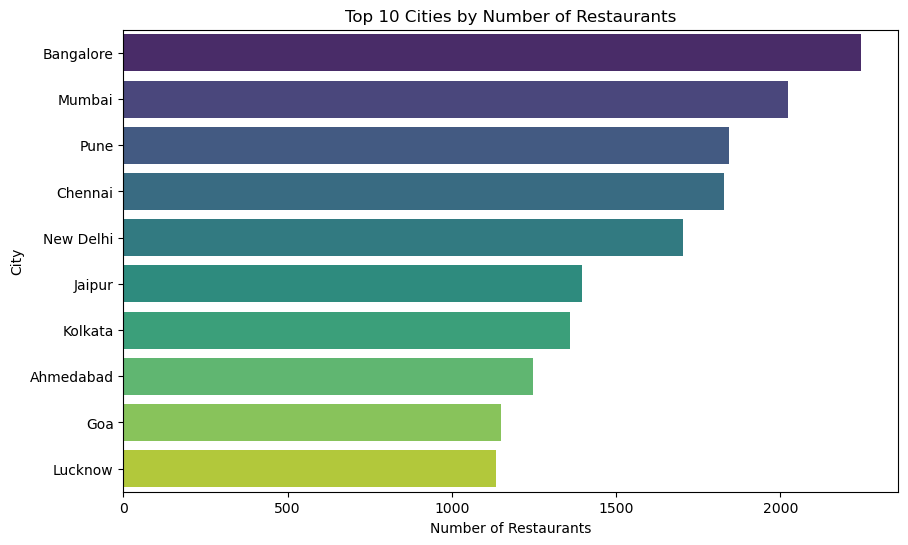

In [28]:
city_counts = data["city"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=city_counts.values, y=city_counts.index, palette="viridis")
plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")
plt.show()

## Observation

- Bengaluru has the highest number of restaurants in the dataset.
- Mumbai and Pune follow closely.
- The distribution shows that restaurant listings are concentrated in a few major cities.
- Cities with fewer restaurants have a relatively smaller presence on the Zomato platform.



### Business Question 2:
#### Which cuisines are the most popular among customers?

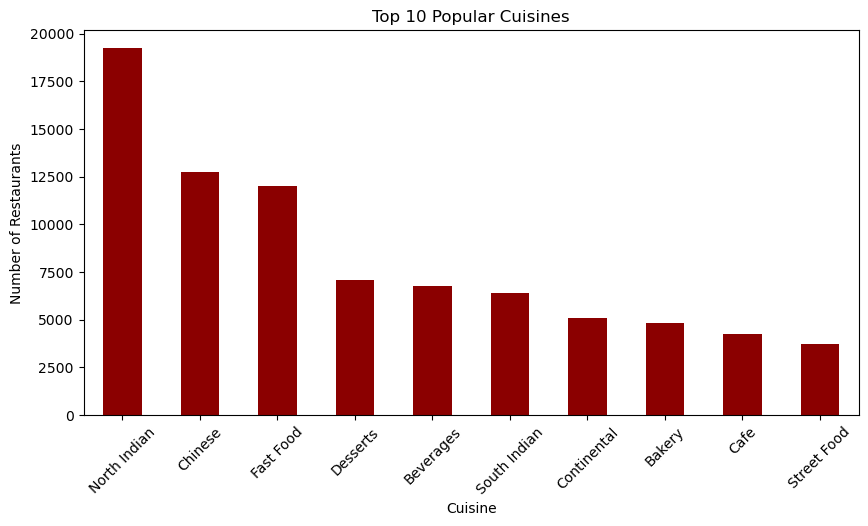

In [33]:
# Count most popular cuisines
top_cuisines = (
    data["cuisines"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)


plt.figure(figsize=(10,5))
top_cuisines.plot(kind="bar", color="darkred")

plt.title("Top 10 Popular Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

## Observation
- North Indian is the most commonly available cuisine among restaurants listed on Zomato.
- Other popular cuisines include Chinese and Fast Food.
- The results show that customers have a preference for widely available and commonly consumed cuisines.
- Some cuisines have fewer listings, indicating lower availability or niche customer demand.

### Business Question 3: 
#### What is the average cost for two people across different cities?

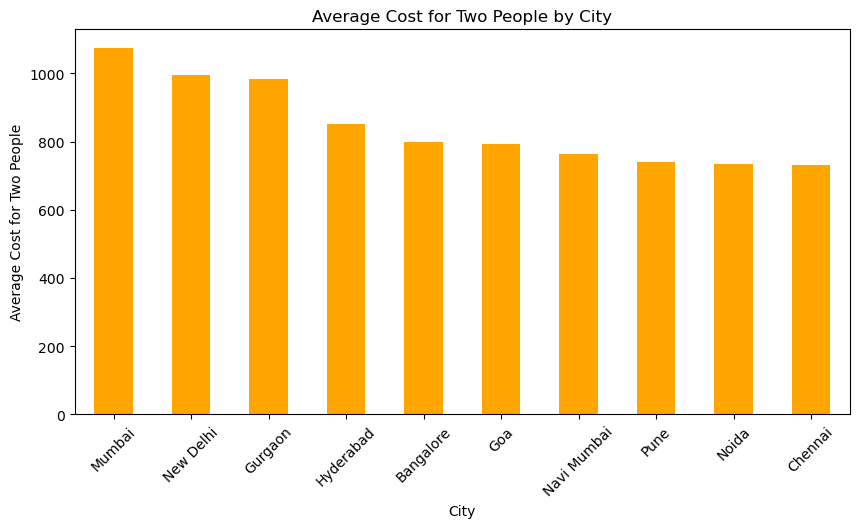

In [34]:
# Calculate average cost for two people by city
avg_cost_city = (
    data.groupby("city")["average_cost_for_two"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)


plt.figure(figsize=(10,5))
avg_cost_city.plot(kind="bar", color="orange")

plt.title("Average Cost for Two People by City")
plt.xlabel("City")
plt.ylabel("Average Cost for Two People")
plt.xticks(rotation=45)
plt.show()

## Observation
has the highest average cost for two people among the listed cities.
Cities such as __________ and __________ also show higher dining costs compared to other cities.
Some cities have relatively lower average costs, indicating more affordable dining options.
The variation in cost suggests differences in restaurant pricing, customer segments, and market conditions across cities.

### Business Question 4:
#### Do restaurants offering online delivery receive higher customer ratings than those that do not?

delivery
0      2.712039
No     2.815873
Yes    3.475306
Name: aggregate_rating, dtype: float64


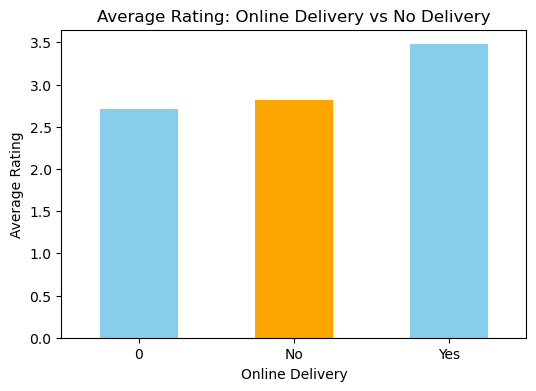

In [36]:
# Average rating based on online delivery
delivery_rating = data.groupby("delivery")["aggregate_rating"].mean()

print(delivery_rating)

plt.figure(figsize=(6,4))
delivery_rating.plot(kind="bar", color=["skyblue", "orange"])

plt.title("Average Rating: Online Delivery vs No Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.show()

## Observation
- Restaurants offering online delivery (Yes) have the highest average rating, approximately 3.5.
- Restaurants without online delivery (No) have a lower average rating of around 2.8.
- The results indicate that restaurants providing online delivery tend to receive slightly better ratings compared to those without delivery.
- The difference suggests that online delivery availability may contribute to customer satisfaction by providing more convenience and accessibility.

### Business Question 5: 
#### Does restaurant cost influence customer ratings?

cost_category
Low       2.958514
Medium    3.583333
High      3.600000
Name: aggregate_rating, dtype: float64


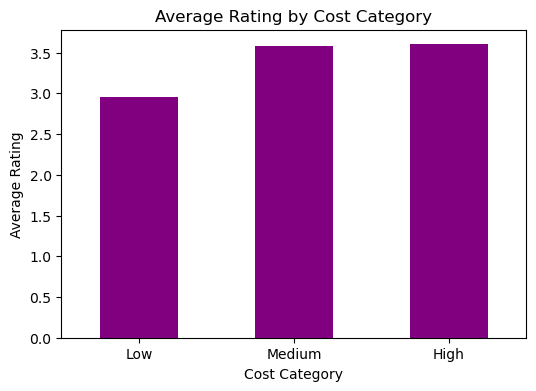

In [54]:
# cost categories
data["cost_category"] = pd.cut(
    data["average_cost_for_two"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

# Calculate average rating by cost category
cost_rating = data.groupby("cost_category")["aggregate_rating"].mean()

print(cost_rating)

plt.figure(figsize=(6,4))
cost_rating.plot(kind="bar", color="purple")

plt.title("Average Rating by Cost Category")
plt.xlabel("Cost Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.show()

## Observation
- High and Medium cost restaurants have the highest average ratings (around 3.5), while Low cost restaurants have lower ratings (around 3.0).
- This suggests that higher-priced restaurants generally receive better ratings compared to lower-priced ones.

### Business Question 6: 
#### Which restaurants have the highest customer ratings and the most votes?

In [58]:
# Top restaurants based on votes among highly rated restaurants
top_restaurants = (
    data[data["aggregate_rating"] >= 4]
    .sort_values("votes", ascending=False)
    [["name", "city", "aggregate_rating", "votes"]]
    .head(10)
)

top_restaurants

,name,city,aggregate_rating,votes
77763,Bawarchi,Hyderabad,4.5,42539
19636,Byg Brewski Brewing Company,Bangalore,4.9,18967
19648,Toit,Bangalore,4.6,15705
19641,Truffles,Bangalore,4.6,15582
53891,Hauz Khas Social,New Delhi,4.8,14751
19677,AB's - Absolute Barbecues,Bangalore,4.8,13095
77720,Paradise,Secunderabad,4.7,12829
77907,Shah Ghouse Hotel & Restaurant,Hyderabad,4.2,12471
114360,Peter Cat,Kolkata,4.2,11856
19667,The Black Pearl,Bangalore,4.7,11776


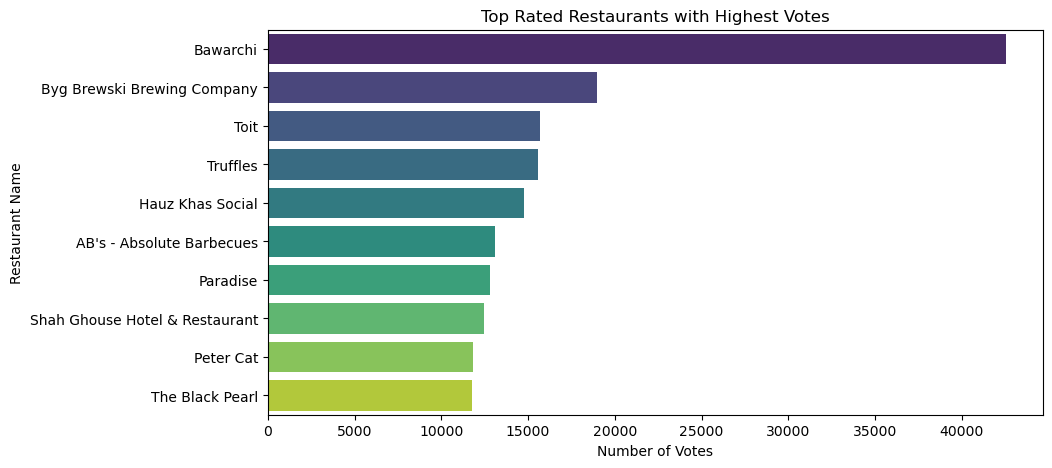

In [59]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_restaurants,
    x="votes",
    y="name",
    palette="viridis"
)

plt.title("Top Rated Restaurants with Highest Votes")
plt.xlabel("Number of Votes")
plt.ylabel("Restaurant Name")
plt.show()

## Observation
- Among the selected restaurants, Bawarchi has the highest number of customer votes, indicating strong popularity and customer engagement.
- Restaurants with higher vote counts generally have greater visibility and customer trust.
- High ratings combined with a large number of votes represent better-performing restaurants on the platform.

### Business Question 7: 
#### Is there a relationship between the number of customer votes and restaurant ratings?

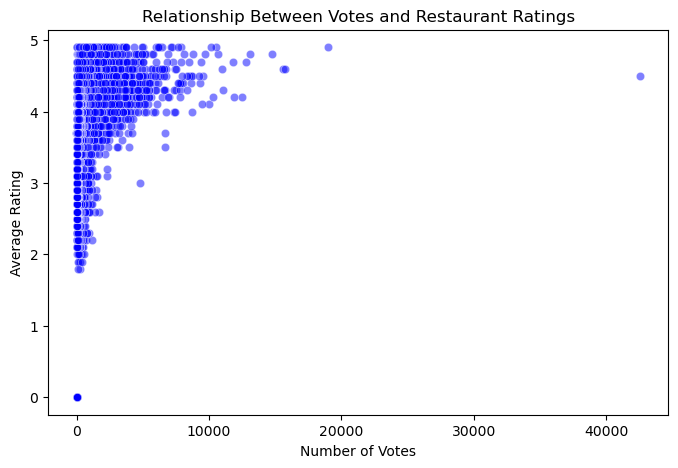

In [61]:
# Relationship between votes and ratings

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="votes",
    y="aggregate_rating",
    alpha=0.5,
    color="blue"
)

plt.title("Relationship Between Votes and Restaurant Ratings")
plt.xlabel("Number of Votes")
plt.ylabel("Average Rating")
plt.show()

## Observation
- The scatter plot shows the relationship between customer votes and restaurant ratings.
- Restaurants with higher numbers of votes generally tend to have better ratings.
- However, the relationship is not very strong, indicating that popularity (votes) does not always guarantee higher ratings.

### Business Question 8:
#### Which price range (Low, Medium, High) contains the largest number of restaurants?

price_range
1    28818
2    16582
3     7370
4     2798
Name: count, dtype: int64


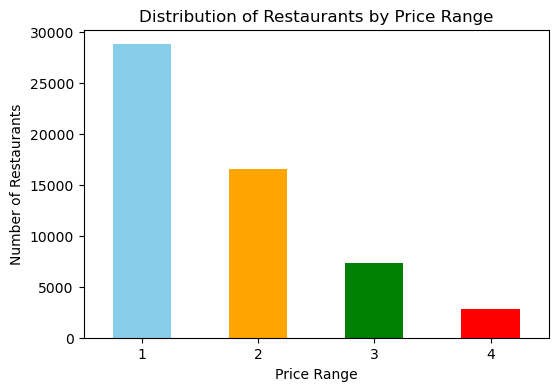

In [64]:
# Count restaurants by price range

price_counts = data["price_range"].value_counts()

print(price_counts)

plt.figure(figsize=(6,4))

price_counts.plot(
    kind="bar",
    color=["skyblue", "orange", "green","red"]
)

plt.title("Distribution of Restaurants by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)
plt.show()

## Observation
- Price Range 1 contains the highest number of restaurants compared to other price categories.
- This indicates that most restaurants in the dataset belong to Price Range 1.
- The number of restaurants decreases across the other price ranges, showing fewer listings in those categories.

### Business Question 9: 
#### Which cities have the highest average restaurant ratings?

city
Gurgaon         3.828525
Secunderabad    3.822222
Hyderabad       3.755839
Kolkata         3.751947
New Delhi       3.727347
Mumbai          3.709298
Bangalore       3.698175
Noida           3.620307
Chennai         3.597701
Pune            3.509224
Name: aggregate_rating, dtype: float64


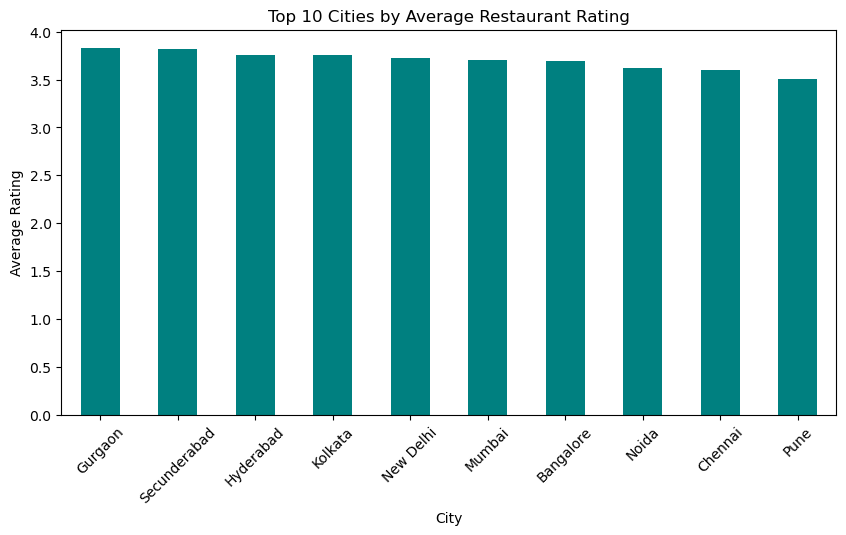

In [66]:
# Calculate average rating by city

city_rating = (
    data.groupby("city")["aggregate_rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(city_rating)

plt.figure(figsize=(10,5))

city_rating.plot(
    kind="bar",
    color="teal"
)

plt.title("Top 10 Cities by Average Restaurant Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

## Observation
- Gurgaon has the highest average restaurant rating among the cities analyzed.
- Other cities also show strong average ratings, indicating better customer satisfaction.
- The variation in city-wise ratings suggests differences in restaurant quality, service, and customer experience.

### Business Question 10: 
#### What are the key factors (price, cuisine, online delivery, table booking, and votes) that influence restaurant ratings?

### 1. Rating vs Votes

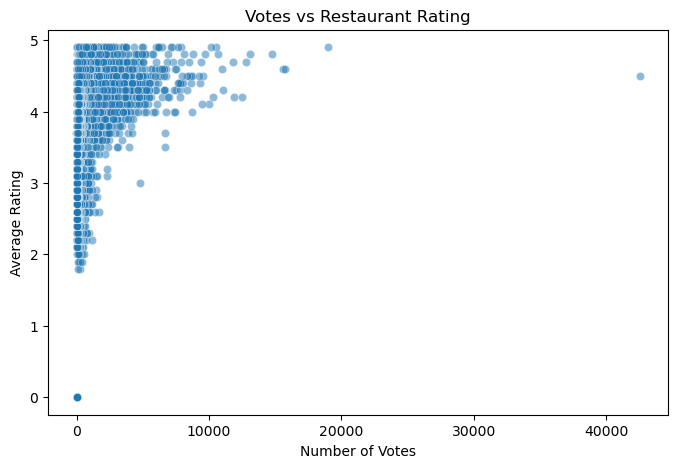

In [67]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="votes",
    y="aggregate_rating",
    alpha=0.5
)

plt.title("Votes vs Restaurant Rating")
plt.xlabel("Number of Votes")
plt.ylabel("Average Rating")
plt.show()


### 2. Rating vs Average Cost

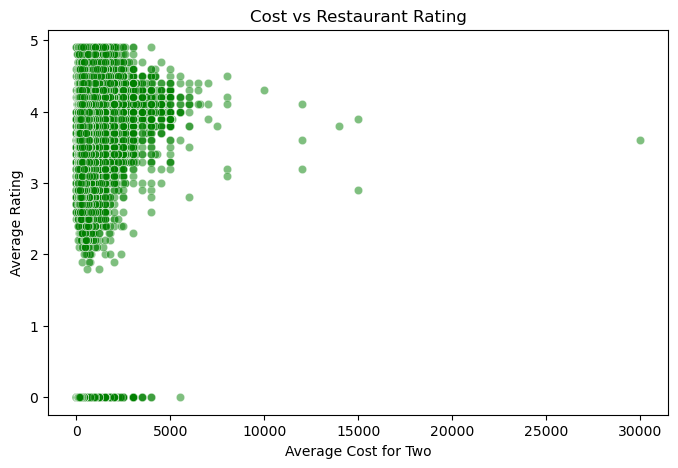

In [69]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="average_cost_for_two",
    y="aggregate_rating",
    alpha=0.5,
    color="green"
)

plt.title("Cost vs Restaurant Rating")
plt.xlabel("Average Cost for Two")
plt.ylabel("Average Rating")
plt.show()

### 3. Rating by Delivery Availability

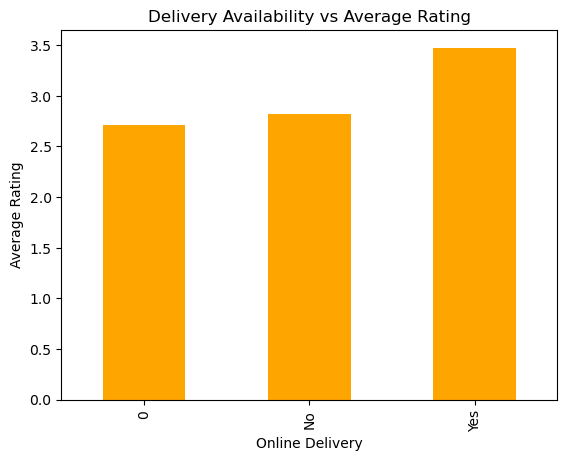

In [70]:
delivery_rating = data.groupby("delivery")["aggregate_rating"].mean()

delivery_rating.plot(
    kind="bar",
    color="orange"
)

plt.title("Delivery Availability vs Average Rating")
plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")
plt.show()

## Observation
- The Votes vs Rating plot shows that most restaurants are concentrated on the lower side of votes, while only a few restaurants receive a very high number of votes. Higher customer engagement does not always guarantee higher ratings.
- The Cost vs Rating plot shows that most restaurants are concentrated in the lower cost range, with no strong direct relationship between higher cost and better ratings.
- The Delivery Availability plot shows that the majority of restaurants offer online delivery, indicating that delivery availability is a common feature among restaurants in the dataset.

# Key Findings & Business Insights

## Key Findings

- Major cities have the highest number of restaurants listed on Zomato, showing higher restaurant activity and customer demand in these locations.
- A few cuisines dominate the platform, indicating strong customer preference for popular food categories.
- Most restaurants belong to the lower price category, showing that affordable restaurants have a larger presence in the dataset.
- Restaurants offering online delivery have slightly higher average ratings compared to restaurants without delivery.
- Higher-cost restaurants tend to have better ratings, but cost alone does not determine customer satisfaction.
- Restaurants with higher votes generally have better visibility and customer engagement. Bawarchi received the highest customer votes among the analyzed restaurants.
- The relationship between votes and ratings is not very strong, indicating that ratings depend on multiple factors.
- Some cities have higher average ratings, showing better customer satisfaction and restaurant performance.

## Business Insights

- Restaurants can focus on cities with higher restaurant concentration to target larger customer bases.
- Offering online delivery can help restaurants improve accessibility and customer convenience.
- Maintaining food quality, service, and customer experience is more important than pricing alone for achieving higher ratings.
- Restaurants should encourage customer feedback and reviews to improve visibility and trust.
- Popular cuisines and customer preferences can help businesses design better menu strategies.
- Pricing should be planned according to customer expectations to provide better value.